In [1]:
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from model import *
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import torch.nn.utils.prune as prune
from fvcore.nn import FlopCountAnalysis
import copy


print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
print(f"GPU     : {torch.cuda.get_device_name(0)}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
with h5py.File("dataset/Dataset_Specific_Unlabelled.h5", "r") as f:
    for key in f.keys():
        print(key, f[key].shape)



PyTorch : 2.12.0.dev20260217+cu128
CUDA    : True
GPU     : NVIDIA GeForce RTX 5060 Laptop GPU
jet (60000, 125, 125, 8)


In [2]:

# Classifier Model
class SparseClassifier(nn.Module):
    def __init__(self, in_channels=8):
        super().__init__()

        #Encoder
        self.enc1  = SubmanifoldSparseConv2d(in_channels, 32,  3)
        self.enc2  = SubmanifoldSparseConv2d(32,          64,  3)
        self.down1 = StridedSparseConv2d    (64,          64,  3, stride=2)
        self.enc3  = SubmanifoldSparseConv2d(64,          128, 3)
        self.down2 = StridedSparseConv2d    (128,         128, 3, stride=2)

        #Binary Classification
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  
            nn.Flatten(),        
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),    
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 16),    
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(8, 1),         
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x, mask):
        # Encoder (frozen or fine-tuned)
        z, m = self.enc1(x, mask);  z = self.relu(z)
        z, m = self.enc2(z, m);     z = self.relu(z)
        z, m = self.down1(z, m);    z = self.relu(z)
        z, m = self.enc3(z, m);     z = self.relu(z)
        z, m = self.down2(z, m);    z = self.relu(z)

        z = z * m.float()

        logit = self.classifier(z) 
        return logit.squeeze(1)     


def load_pretrained_encoder(classifier, autoencoder_path):

    checkpoint = torch.load(autoencoder_path, map_location=device)
    if 'model_state_dict' in checkpoint:
        state_dict = checkpoint['model_state_dict']
    else:
        state_dict = checkpoint
    # Only load encoder layers
    encoder_keys = ['enc1', 'enc2', 'down1', 'enc3', 'down2']
    model_dict   = classifier.state_dict()

    pretrained = {k: v for k, v in state_dict.items()
                  if any(k.startswith(key) for key in encoder_keys)}

    model_dict.update(pretrained)
    classifier.load_state_dict(model_dict)

    loaded = list(pretrained.keys())
    print(f"Loaded {len(loaded)} pretrained encoder weights")
    return classifier

In [3]:
pruning_results = []
dummy_x    = torch.zeros(1, 8, 125, 125).to(device)
dummy_mask = torch.ones(1, 1, 125, 125).bool().to(device)

dataset    = H5LabelledDataset("dataset/Dataset_Specific_labelled.h5")

val_size   = int(0.2 * len(dataset))
train_size = len(dataset) - val_size
train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size],generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=100, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=100, shuffle=False, num_workers=0)

print(f"Train: {train_size} | Val: {val_size}")

    # Model 
classifier = SparseClassifier(in_channels=8).to(device)
classifier = load_pretrained_encoder(classifier, 'models/sparse_autoencoder_checkpoint_2.pth')

    #Loss
criterion = nn.BCEWithLogitsLoss() 
    

Train: 8000 | Val: 2000
Loaded 30 pretrained encoder weights


In [4]:

checkpoint = torch.load("models/sparse_classifier.pth", map_location=device)
classifier = SparseClassifier(in_channels=8).to(device)
classifier.load_state_dict(checkpoint['model_state_dict'])

CONV_LAYERS = [
    (classifier.enc1,  'enc1'),
    (classifier.enc2,  'enc2'),
    (classifier.enc3,  'enc3'),
    (classifier.down1, 'down1'),
    (classifier.down2, 'down2'),
]

pruning_results = []

for ratio in [0.0, 0.1, 0.2, 0.3, 0.5, 0.7]:
    pruned_model = copy.deepcopy(classifier)

    conv_layers_pruned = [
        (pruned_model.enc1.conv,  'weight'),
        (pruned_model.enc2.conv,  'weight'),
        (pruned_model.enc3.conv,  'weight'),
        (pruned_model.down1.conv, 'weight'),
        (pruned_model.down2.conv, 'weight'),
    ]

    if ratio > 0:
        prune.global_unstructured(
            conv_layers_pruned,
            pruning_method=prune.L1Unstructured,
            amount=ratio,
        )
        # Remove masks and make pruning permanent
        for module, name in conv_layers_pruned:
            prune.remove(module, name)

    # Count actual nonzero weights as a proxy for effective FLOPs
    total_weights = 0
    nonzero_weights = 0
    for module, _ in conv_layers_pruned:
        w = module.weight
        total_weights   += w.numel()
        nonzero_weights += w.nonzero().size(0)

    sparsity        = 1.0 - nonzero_weights / total_weights
    effective_ratio = nonzero_weights / total_weights  # fraction of weights actually doing work

    # FLOPs on a realistic sparse input (not all-ones mask)
    # Use a real val sample instead of dummy_mask
    pruned_model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for X, mask, y in val_loader:
            X, mask, y = X.to(device), mask.to(device), y.to(device)
            logits = pruned_model(X, mask)
            preds  = (logits > 0).float()
            val_correct += (preds == y).sum().item()
            val_total   += y.size(0)

    val_acc = val_correct / val_total * 100
    error   = 1 - (val_acc / 100)

    # FLOPs: scale baseline by nonzero fraction (honest estimate for unstructured pruning)
    baseline_flops = FlopCountAnalysis(pruned_model, (dummy_x, dummy_mask)).total() / 1e6
    effective_flops = baseline_flops * effective_ratio

    pruning_results.append((ratio, effective_flops, error, val_acc, sparsity))
    print(f"Ratio {ratio:.1f} | Sparsity {sparsity:.1%} | "
          f"Val Acc {val_acc:.2f}% | Error {error:.4f} | "
          f"Effective FLOPs {effective_flops:.1f}M")

Unsupported operator aten::mul encountered 11 time(s)
Unsupported operator aten::sub encountered 3 time(s)
Unsupported operator aten::adaptive_max_pool2d encountered 2 time(s)


Ratio 0.0 | Sparsity 0.0% | Val Acc 82.25% | Error 0.1775 | Effective FLOPs 1539.5M


Unsupported operator aten::mul encountered 11 time(s)
Unsupported operator aten::sub encountered 3 time(s)
Unsupported operator aten::adaptive_max_pool2d encountered 2 time(s)


Ratio 0.1 | Sparsity 10.0% | Val Acc 81.40% | Error 0.1860 | Effective FLOPs 1385.6M


Unsupported operator aten::mul encountered 11 time(s)
Unsupported operator aten::sub encountered 3 time(s)
Unsupported operator aten::adaptive_max_pool2d encountered 2 time(s)


...

Ratio 0.3 | Sparsity 30.0% | Val Acc 76.90% | Error 0.2310 | Effective FLOPs 1077.7M


Unsupported operator aten::mul encountered 11 time(s)
Unsupported operator aten::sub encountered 3 time(s)
Unsupported operator aten::adaptive_max_pool2d encountered 2 time(s)


Ratio 0.5 | Sparsity 50.0% | Val Acc 81.30% | Error 0.1870 | Effective FLOPs 769.8M


Unsupported operator aten::mul encountered 11 time(s)
Unsupported operator aten::sub encountered 3 time(s)
Unsupported operator aten::adaptive_max_pool2d encountered 2 time(s)


Ratio 0.7 | Sparsity 70.0% | Val Acc 53.75% | Error 0.4625 | Effective FLOPs 461.9M


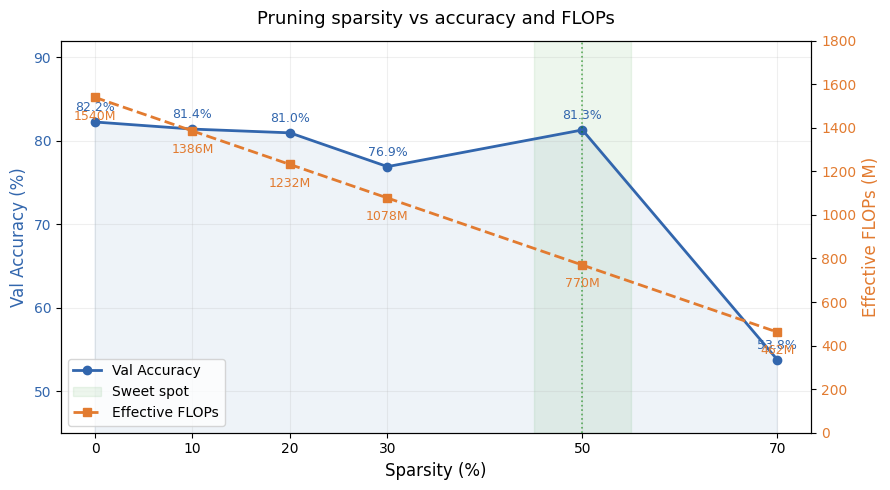

In [ ]:


sparsity = [0, 10, 20, 30, 50, 70]
acc      = [82.25, 81.40, 80.95, 76.90, 81.30, 53.75]
flops    = [1539.5, 1385.6, 1231.6, 1077.7, 769.8, 461.9]

fig, ax1 = plt.subplots(figsize=(9, 5))

# --- Accuracy (left axis) ---
color_acc = '#3266ad'
ax1.plot(sparsity, acc, color=color_acc, marker='o', linewidth=2,
         markersize=6, label='Val Accuracy')
ax1.fill_between(sparsity, acc, alpha=0.08, color=color_acc)
ax1.set_xlabel('Sparsity (%)', fontsize=12)
ax1.set_ylabel('Val Accuracy (%)', color=color_acc, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_acc)
ax1.set_ylim(45, 92)
ax1.set_xticks(sparsity)

# annotate each point
for x, y in zip(sparsity, acc):
    ax1.annotate(f'{y:.1f}%', xy=(x, y), xytext=(0, 8),
                 textcoords='offset points', ha='center',
                 fontsize=9, color=color_acc)

# --- FLOPs (right axis) ---
color_flops = '#e27b30'
ax2 = ax1.twinx()
ax2.plot(sparsity, flops, color=color_flops, marker='s', linewidth=2,
         markersize=6, linestyle='--', label='Effective FLOPs')
ax2.set_ylabel('Effective FLOPs (M)', color=color_flops, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_flops)
ax2.set_ylim(0, 1800)

# annotate each point
for x, y in zip(sparsity, flops):
    ax2.annotate(f'{y:.0f}M', xy=(x, y), xytext=(0, -16),
                 textcoords='offset points', ha='center',
                 fontsize=9, color=color_flops)

# --- Highlight the sweet spot ---
ax1.axvspan(45, 55, alpha=0.07, color='green', label='Sweet spot')
ax1.axvline(x=50, color='green', linestyle=':', linewidth=1.2, alpha=0.6)

# --- Legend ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left', fontsize=10)

ax1.set_title('Pruning sparsity vs accuracy and FLOPs', fontsize=13, pad=12)
ax1.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('pruning_results.png', dpi=150, bbox_inches='tight')
plt.show()